In [29]:
import pandas as pd, polars as pl, matplotlib.pyplot as plt
import os, subprocess

In [30]:
import datetime as dt

# Data reading

## load all 2024 months of taxi rides

In [31]:
# i am reusing loads used in exercises because they have nice way to prevent from 
#repeated redownload 
DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)

for month in range(1, 13):
    if not os.path.exists(f"{DATA_DIR}/{month}.parquet"):
        subprocess.run(
            [
                "wget",
                f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{month:02}.parquet",
                "-O",
                f"{DATA_DIR}/{month}.parquet",
            ]
        )


total_size = sum(
    os.path.getsize(f"{DATA_DIR}/{month}.parquet") for month in range(1, 13)
)  # bytes
total_size_mb = total_size // (1024 * 1024)
print(f"Total dataset size: {total_size_mb} MB")

Total dataset size: 604 MB


##    - also load taxi zone lookup data


In [32]:
#also i am borroing this one
if not os.path.exists(f"{DATA_DIR}/taxi_zone_lookup.csv"):
    subprocess.run(
        [
            "wget",
            "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
            "-O",
            f"{DATA_DIR}/taxi_zone_lookup.csv",
        ]
    )

## include only rides starting in 2024 and ending at most at 01.01.2025

In [33]:
df = pl.read_parquet(f"{DATA_DIR}/1.parquet")

In [34]:
df = (
    df.filter
    (
        (pl.col("tpep_pickup_datetime").dt.year() == 2024)
        & (pl.col("tpep_dropoff_datetime").dt.date() <= dt.date(2025,1,1))
    )
)

## optimize data types, particularly for integers and categorical strings

In [35]:
df.describe()

statistic,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
str,f64,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2.964609e6,"""2964609""","""2964609""",2.824447e6,2.964609e6,2.824447e6,"""2824447""",2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.964609e6,2.824447e6,2.824447e6
"""null_count""",0.0,"""0""","""0""",140162.0,0.0,140162.0,"""140162""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140162.0,140162.0
"""mean""",1.754203,"""2024-01-17 01:02:09.401078""","""2024-01-17 01:17:46.178878""",1.339279,3.652171,2.069365,null,166.01786,165.116522,1.161268,18.175072,1.451595,0.483383,3.335878,0.527022,0.975632,26.801522,2.256126,0.141161
"""std""",0.432591,null,null,0.850279,225.463143,9.823245,null,63.623961,69.31536,0.580867,18.949561,1.804098,0.117759,3.896555,2.128311,0.218362,23.385594,0.823267,0.487624
"""min""",1.0,"""2024-01-01 00:00:00""","""2024-01-01 00:02:42""",0.0,0.0,1.0,"""N""",1.0,1.0,0.0,-899.0,-7.5,-0.5,-80.0,-80.0,-1.0,-900.0,-2.5,-1.75
"""25%""",2.0,"""2024-01-09 15:59:24""","""2024-01-09 16:16:28""",1.0,1.0,1.0,null,132.0,114.0,1.0,8.6,0.0,0.5,1.0,0.0,1.0,15.38,2.5,0.0
"""50%""",2.0,"""2024-01-17 10:45:42""","""2024-01-17 11:03:57""",1.0,1.68,1.0,null,162.0,162.0,1.0,12.8,1.0,0.5,2.7,0.0,1.0,20.1,2.5,0.0
"""75%""",2.0,"""2024-01-24 18:23:56""","""2024-01-24 18:40:30""",1.0,3.11,1.0,null,234.0,234.0,1.0,20.5,2.5,0.5,4.12,0.0,1.0,28.56,2.5,0.0
"""max""",6.0,"""2024-02-01 00:01:15""","""2024-02-02 13:56:52""",9.0,312722.3,99.0,"""Y""",265.0,265.0,4.0,5000.0,14.25,4.0,428.0,115.92,1.0,5000.0,2.5,1.75


In [36]:
df = df.lazy().with_columns(
    pl.col("VendorID").cast(pl.Int8),
    pl.col("tpep_pickup_datetime").cast(pl.Datetime),
    pl.col("tpep_dropoff_datetime").cast(pl.Datetime),
    pl.col("passenger_count").cast(pl.Int32),
    pl.col("trip_distance").cast(pl.Float32),
    pl.col("RatecodeID").cast(pl.Int8),
    pl.col("store_and_fwd_flag").cast(pl.Utf8),
    pl.col("PULocationID").cast(pl.Int16),
    pl.col("DOLocationID").cast(pl.Int16),
    pl.col("payment_type").cast(pl.Int8),
    pl.col("fare_amount").cast(pl.Float32),
    pl.col("extra").cast(pl.Float32),
    pl.col("mta_tax").cast(pl.Float32),
    pl.col("tip_amount").cast(pl.Float32),
    pl.col("tolls_amount").cast(pl.Float32),
    pl.col("improvement_surcharge").cast(pl.Float32),
    pl.col("total_amount").cast(pl.Float32),
    pl.col("congestion_surcharge").cast(pl.Float32),
    pl.col("Airport_fee").cast(pl.Float32)
).collect()

In [37]:
print(df.schema)

Schema({'VendorID': Int8, 'tpep_pickup_datetime': Datetime(time_unit='us', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='us', time_zone=None), 'passenger_count': Int32, 'trip_distance': Float32, 'RatecodeID': Int8, 'store_and_fwd_flag': String, 'PULocationID': Int16, 'DOLocationID': Int16, 'payment_type': Int8, 'fare_amount': Float32, 'extra': Float32, 'mta_tax': Float32, 'tip_amount': Float32, 'tolls_amount': Float32, 'improvement_surcharge': Float32, 'total_amount': Float32, 'congestion_surcharge': Float32, 'Airport_fee': Float32})


# Data cleaning and filtering

## all steps in one until it crashes and burns


In [38]:
df = (
    # lazify dataset otherwise my laptop would implode into black hole
    df.lazy().with_columns(
    # fill NULL values in `passengers_count` with 1    
    pl.col("passenger_count").fill_null(1)
    ).filter(
        # remove rides with zero passengers
        pl.col("passenger_count") > 0
    ).with_columns(
        (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")
         ).dt.total_minutes().alias("trip_duration")
    ).filter(
        # remove rides lasting over 2 hours
        pl.col("trip_duration") <=120
    ).with_columns(
        # if a ride has over 6 passengers, replace the value with 6
        pl.col("passenger_count").clip(upper_bound=6), #thats actually nice function
        # in all money-related columns, replace values with absolute value to fix negative amounts
        pl.col([
            'fare_amount',
            'extra',
            'mta_tax',
            'tip_amount',
            'tolls_amount',
            'improvement_surcharge',
            'total_amount',
            'congestion_surcharge',
            'Airport_fee']).abs()
    ).filter(
        # remove rides with over 1000 dollars in any money-related column
        # i tried ([list] <=1000).all() but it didn't work so using on-by-one instead
        pl.col('fare_amount') <= 1000,
        pl.col('extra') <= 1000,
        pl.col('mta_tax') <= 1000,
        pl.col('tip_amount') <= 1000,
        pl.col('tolls_amount') <= 1000,
        pl.col('improvement_surcharge') <= 1000,
        pl.col('total_amount') <= 1000,
        pl.col('congestion_surcharge') <= 1000,
        pl.col('Airport_fee') <= 1000
    ).filter(
        # remove rows with values of `RatecodeID` 
        # or `VendorID` missing or outside those defined in the data dictionary
        pl.col("VendorID").is_not_null(),
        pl.col("VendorID").is_in([1, 2,6,7]), #apparently these are viable
        pl.col('RatecodeID').is_not_null(),
        pl.col('RatecodeID').is_in([1, 2, 3, 4, 5, 6, 99])
    ).collect() # de-lazyfy dataframe
)


In [39]:
#checking with df.schema() cause df.describe shows weird data types for some reason 
print(df.schema)

Schema({'VendorID': Int8, 'tpep_pickup_datetime': Datetime(time_unit='us', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='us', time_zone=None), 'passenger_count': Int32, 'trip_distance': Float32, 'RatecodeID': Int8, 'store_and_fwd_flag': String, 'PULocationID': Int16, 'DOLocationID': Int16, 'payment_type': Int8, 'fare_amount': Float32, 'extra': Float32, 'mta_tax': Float32, 'tip_amount': Float32, 'tolls_amount': Float32, 'improvement_surcharge': Float32, 'total_amount': Float32, 'congestion_surcharge': Float32, 'Airport_fee': Float32, 'trip_duration': Int64})


# Data transformation

In [40]:
df2 = (
    df.lazy().with_columns(
        # combine payment type values for 
        # `"No charge"`, `"Dispute"`, `"Unknown"` and `"Voided trip"` into one type,
        # i hope thsi works 
        # i actually like the fact i can chain these 
        # i am mapping 0 - flex fare trip to others
        pl.col("payment_type").cast(pl.Utf8).replace({
            "0": "other",
            "1": "credit card",
            "2": "cash",
            "3": "other",
            "4": "other",
            "5": "other",
            "6": "other"
        }).alias("payment_type")
    ).collect()
)

In [41]:
# i am borrowing this from, exercise workbook
df_taxi_zones = pl.read_csv("data/taxi_zone_lookup.csv").lazy()

In [42]:
df2 = (
    df2.lazy().with_columns(
        # combine payment type values for 
        # `"No charge"`, `"Dispute"`, `"Unknown"` and `"Voided trip"` into one type,
        # i hope thsi works 
        # i actually like the fact i can chain these 
        # i am mapping 0 - flex fare trip to others
        # i originally used utf8 for mapping function and then jumped to categorical
        pl.col("payment_type").cast(pl.Utf8).replace({
            "0": "other",
            "1": "credit card",
            "2": "cash",
            "3": "other",
            "4": "other",
            "5": "other",
            "6": "other"
        }).cast(pl.Categorical).alias("payment_type"),
        pl.col("store_and_fwd_flag").cast(pl.Categorical)
        # replace `PULocationID` and `DOLocationID` 
        # with borough names by 
        # joining taxi zone lookup and removing
        # unnecessary columns
        ).join(
            df_taxi_zones, left_on="PULocationID", right_on="LocationID"
        ).join(
            df_taxi_zones, left_on="DOLocationID", right_on="LocationID", suffix="_D"
        ).rename(
            {"Borough": "pickup_borough",
            "Borough_D": "dropoff_borough",
            "Airport_fee": "airport_fee"}
        ).drop(
            {"PULocationID", "DOLocationID"}
        # add boolean variable `is_airport_ride`, 
        # true if there is non-zero airport fee
        # add boolean variable `is_rush_hour`, 
        # rush hours are defined as 6:30–9:30 and 15:30-20:00 during weekdays
        ).with_columns(
            ((pl.col('airport_fee') > 0).alias('is_airport_ride')),
            ((pl.col('tpep_pickup_datetime').dt.weekday()< 6) #i hope this week doesnt start with sunday 
            & (
                (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(6, 30))
                    & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(9, 30))
                ) | (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(15, 30))
            & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(20, 0))
                )
            ) 
            ).alias("is_rush_hour")
        ).collect()
)

# Feature extraction

## dummy encoding

In [ ]:
df3 = (
    df2.to_dummies(
        columns=["payment_type", "pickup_borough", "dropoff_borough"]
    ).lazy().with_columns( 
        #open lazification sequence
        #make some dates
        pl.col('tpep_pickup_datetime').dt.date().alias('date')
    )
    .group_by("date")
    .agg(
        # - add integer variables for counting daily events:
        #      - total number of rides (target variable)
        #      - number of airport rides
        #      - number of rush hour rides
        pl.len().alias("total_rides"),
        pl.col("is_airport_ride").sum().alias("airport_rides"),
        pl.col("is_rush_hour").sum().alias("rush_hour_rides"),
        #    - add features aggregating daily rides information:
        #      - average fare amount
        #      - median distance
        #      - sum of total amounts
        #      - total amount paid by card, cash, and other
        #      - total congestion surcharge
        #      - total number of passengers)
        #since i have already made dummies/one-hots i will use them instead of ifs 
        #if its paid by card then that flag will be non-zero so that was handy
        (pl.col("total_amount") * pl.col("payment_type_credit card")).sum().alias("total_paid_by_card"),
        (pl.col("total_amount") * pl.col("payment_type_cash")).sum().alias("total_paid_by_cash"),
        (pl.col("total_amount") * pl.col("payment_type_other")).sum().alias("total_paid_by_other"),
        # some statistical wikitiki
        pl.col("fare_amount").mean().alias("average_fare_amount"),
        pl.col("trip_distance").median().alias("median_distance"),
        pl.col("total_amount").sum().alias("sum_total_amount")
    )
    .with_columns(
        # it felt wrong to have date attributes at the end so i moved them earlier i nthe execution order, before aggregsation
        # nevermind, actually it made sense cause otherwise i would need to have them in the aggregation 
        # and that would sound like additional effort my machine would not survive
        pl.col("date").dt.quarter().alias("quarter"),
        pl.col("date").dt.month().alias("month"),
        pl.col("date").dt.day().alias("day_of_month"),
        pl.col("date").dt.weekday().alias("day_of_week"),  
        (pl.col("date").dt.weekday() >= 6).alias("is_weekend")
    ).collect()
)
df3

date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,bool
2024-01-03,79566,9140,33389,1.8662e6,416240.1875,49554.277344,20.170843,1.75,2.332076e6,1,1,3,3,false
2024-01-06,90902,6795,0,1.9337e6,360792.59375,53003.574219,17.773657,1.66,2.34757e6,1,1,6,6,true
2024-01-09,85589,5923,38240,1870647.5,300831.34375,43945.914062,17.249916,1.51,2.2155e6,1,1,9,2,false
2024-01-24,100249,6509,42700,2.347968e6,318455.28125,49623.132812,18.046085,1.6,2.7161e6,1,1,24,3,false
2024-01-15,73244,9170,28441,1.8031e6,267640.0625,41303.871094,19.821978,1.7,2.1121e6,1,1,15,1,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-01-11,100460,8419,42215,2.4249e6,360215.96875,53338.675781,18.937138,1.7,2.8385e6,1,1,11,4,false
2024-01-20,99104,5569,0,2.0645e6,315308.9375,53076.640625,16.676249,1.57,2432886.5,1,1,20,6,true
2024-01-23,94507,6709,39565,2188686.5,319718.59375,46614.835938,18.062784,1.61,2.555075e6,1,1,23,2,false


df3.schema()

In [46]:
df3.schema

Schema([('date', Date),
        ('total_rides', UInt32),
        ('airport_rides', UInt32),
        ('rush_hour_rides', UInt32),
        ('total_paid_by_card', Float32),
        ('total_paid_by_cash', Float32),
        ('total_paid_by_other', Float32),
        ('average_fare_amount', Float32),
        ('median_distance', Float32),
        ('sum_total_amount', Float32),
        ('quarter', Int8),
        ('month', Int8),
        ('day_of_month', Int8),
        ('day_of_week', Int8),
        ('is_weekend', Boolean)])

# Data Analysis

In [48]:
# print shape
print(df3.shape)

(32, 15)


In [49]:
#show top rows
df3.head(10)

date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,bool
2024-01-03,79566,9140,33389,1.8662e6,416240.1875,49554.277344,20.170843,1.75,2.332076e6,1,1,3,3,false
2024-01-06,90902,6795,0,1.9337e6,360792.59375,53003.574219,17.773657,1.66,2.34757e6,1,1,6,6,true
2024-01-09,85589,5923,38240,1870647.5,300831.34375,43945.914062,17.249916,1.51,2.2155e6,1,1,9,2,false
2024-01-24,100249,6509,42700,2.347968e6,318455.28125,49623.132812,18.046085,1.6,2.7161e6,1,1,24,3,false
2024-01-15,73244,9170,28441,1.8031e6,267640.0625,41303.871094,19.821978,1.7,2.1121e6,1,1,15,1,false
2024-01-12,98028,8546,38669,2.362366e6,354484.21875,50532.71875,18.906263,1.67,2.7674e6,1,1,12,5,false
2024-01-18,103220,7325,43844,2.4095e6,354590.5625,52359.332031,18.222298,1.6,2816472.5,1,1,18,4,false
2024-01-30,96827,6678,41712,2.221107e6,310968.125,49632.488281,17.715219,1.6,2.5817e6,1,1,30,2,false
2024-01-27,104623,4945,0,2.2387e6,336265.71875,55960.539062,17.198835,1.68,2.6310e6,1,1,27,6,true


In [50]:
#describe statistics
df3.describe()

statistic,date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""32""",32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-01-16 12:00:00""",87196.21875,7359.0,27240.5625,2.0248e6,323004.3125,48790.597656,18.705124,1.691875,2396599.5,1.0,1.03125,15.53125,3.8125,0.25
"""std""",null,19409.457927,1750.810467,17986.500576,436900.6875,73316.007812,9865.368164,1.175646,0.139987,504254.875,0.0,0.176777,9.329054,2.007044,null
"""min""","""2024-01-01""",3.0,1.0,0.0,37.68,52.790001,0.0,16.676249,1.51,90.470001,1.0,1.0,1.0,1.0,0.0
"""25%""","""2024-01-09""",80969.0,6709.0,0.0,1870647.5,304960.4375,47391.980469,18.046085,1.6,2.2894e6,1.0,1.0,8.0,2.0,null
"""50%""","""2024-01-17""",90932.0,7952.0,36870.0,2.1209e6,319718.59375,49986.929688,18.572542,1.67,2.4901e6,1.0,1.0,16.0,4.0,null
"""75%""","""2024-01-24""",99077.0,8411.0,40518.0,2255953.5,354590.5625,53003.574219,19.037434,1.71,2.6768e6,1.0,1.0,23.0,5.0,null
"""max""","""2024-02-01""",104623.0,9828.0,44429.0,2.4978e6,444631.125,59823.253906,22.217703,2.22,2894780.5,1.0,2.0,31.0,7.0,1.0


In [51]:
#print schema
print(df3.schema)

Schema({'date': Date, 'total_rides': UInt32, 'airport_rides': UInt32, 'rush_hour_rides': UInt32, 'total_paid_by_card': Float32, 'total_paid_by_cash': Float32, 'total_paid_by_other': Float32, 'average_fare_amount': Float32, 'median_distance': Float32, 'sum_total_amount': Float32, 'quarter': Int8, 'month': Int8, 'day_of_month': Int8, 'day_of_week': Int8, 'is_weekend': Boolean})


## plottin

array([[<Axes: title={'center': 'total_rides'}>]], dtype=object)

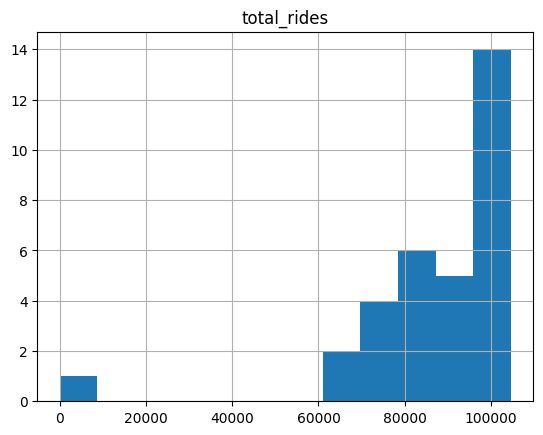

In [58]:
#histogram of values
# for daily total rides
df3.to_pandas().hist("total_rides", bins=12)


<Axes: xlabel='date'>

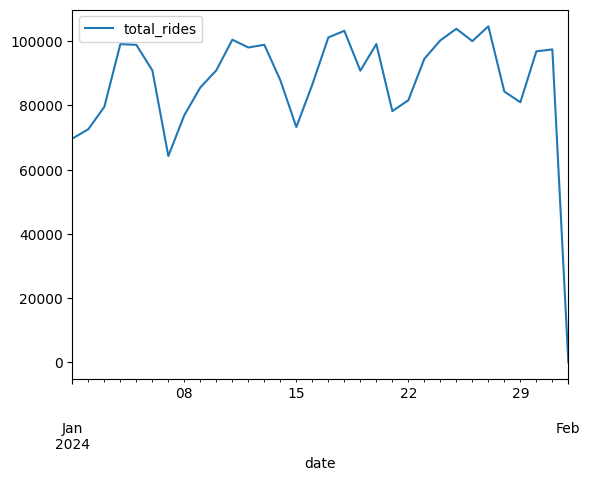

In [62]:
#line polot of total rides over date
df3x = df3.to_pandas().sort_values("date") 
df3x.plot(x="date", y="total_rides", kind="line")